In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.models import Model

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalise images
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

#Reshape
x_train = np.reshape(x_train, (len(x_train),28,28,1))
x_test = np.reshape(x_test, (len(x_test),28,28,1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Noise Added

In [ ]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0,scale=1.0,size=x_train.shape)

x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0,scale=1.0,size=x_test.shape)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

## Build Autoencoder

In [ ]:
input_img = Input(shape=(28,28,1))

x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(16,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)

## Decoder

In [ ]:
x = Conv2D(16,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1,(3,3),activation='sigmoid',padding='same')(x)

## Create Model

In [ ]:
autoencoder = Model(input_img, decoded)

# Compile the Model
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [ ]:
autoencoder.fit(x_train_noisy,x_train,epochs=20,batch_size=128,shuffle=True,validation_data=(x_test_noisy,x_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.1757 - val_loss: 0.1239
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1176 - val_loss: 0.1123
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1113 - val_loss: 0.1092
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1084 - val_loss: 0.1065
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1066 - val_loss: 0.1051
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1052 - val_loss: 0.1038
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1042 - val_loss: 0.1028
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1033 - val_loss: 0.1019
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1025 - val_loss: 0.1012
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1019 - val_loss: 0.1008
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1012 - val_loss: 0.1001
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/st

## Predict

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


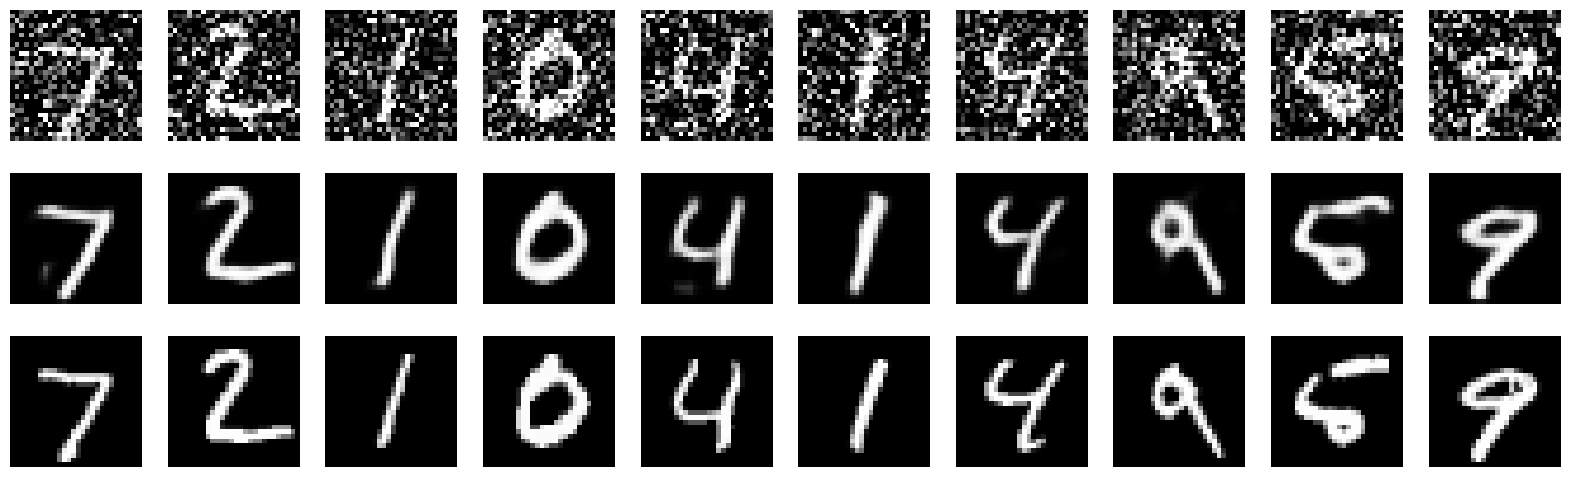

In [ ]:
n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
    plt.axis("off")

    # Reconstructed Image
    ax = plt.subplot(3,n,i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
    plt.axis("off")

    # Original Image
    ax = plt.subplot(3,n,i+2*n+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.axis("off")

plt.show()

## Observations
* The denoising autoencoder successfully removed most of the artificial noise from the MNIST images.
* The reconstructed images were much closer to the original images while preserving the shape of the handwritten digits.
* Both training and validation losses decreased steadily, indicating effective learning.
* Higher noise levels resulted in slightly blurrier reconstructed images, but the digits remained recognizable.
* Overall, the model demonstrated good denoising performance and effectively reconstructed clean images from noisy inputs.